### Q1. Write a Python function that uses simulations to find quantiles of the distribution of the mth order statistic for n normal random variables.

In [1]:
import numpy as np

def morder(m,n,q,R,mu,s):
    
    '''
    m   order statistic to compute
    n   number of normal random variables
    q   the vector of desired quantile points
    R   number of replicates
    mu  mean of the normal distribution
    s   SD of the normal distribution
    '''
    
    data = [] # list to store the m-th order statistic from all replicates
    
    for i in range(R): # loop to generate R replicates
        rv = np.random.normal(mu, s, size=n) # generate n random variables from N(mu,s)
        sort_rv = np.sort(rv) # sort them in ascending order
        data.append(sort_rv[m-1]) # store the m-th r.v
    
    return np.quantile(data, q)

#### Test case 1

In [2]:
m = 60 # order statistic
n = 100 # num of r.v.
q = [.25, .50, .75] # desired quantile points
R = 10 # num of replicates
mu = 0 # mean of the dist
s = 1 # sd of the dist

points = morder(m, n, q, R, mu, s)

for i, point in enumerate(points):
    print("%.d%% quantile is %.2f" % (q[i]*100, point))

25% quantile is 0.23
50% quantile is 0.36
75% quantile is 0.39


#### Test case 2

In [3]:
m = 50 # order statistic
n = 500 # num of r.v.
q = [0.2, 0.3, 0.60, 0.90] # desired quantile points
R = 10 # num of replicates
mu = 5 # mean of the dist
s = 2 # sd of the dist

points = morder(m, n, q, R, mu, s)

for i, point in enumerate(points):
    print("%.d%% quantile is %.2f" % (q[i]*100, point))

20% quantile is 2.32
30% quantile is 2.35
60% quantile is 2.41
90% quantile is 2.53


#### Test case 3

In [4]:
m = 80 # order statistic
n = 1000 # num of r.v.
q = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90] # desired quantile points
R = 100 # num of replicates
mu = 91 # mean of the dist
s = 5 # sd of the dist

points = morder(m, n, q, R, mu, s)

for i, point in enumerate(points):
    print("%.d%% quantile is %.2f" % (q[i]*100, point))

10% quantile is 83.61
20% quantile is 83.75
30% quantile is 83.79
40% quantile is 83.83
50% quantile is 83.90
60% quantile is 84.00
70% quantile is 84.09
80% quantile is 84.22
90% quantile is 84.33


## Q2. Heteroskedasticity simulation

In [5]:
import numpy as np
import numpy.random as npr
import statsmodels.api as sm
import matplotlib.pyplot as plt

def getPval(x,y):
    '''
    Takes predictor and response as input 
    fits least squares
    and returns coefficients, SE, CI, and p_value
    
    x: predictor variable
    y: response variable
    '''
    x = sm.add_constant(x) # add intercept
    model = sm.OLS(y, x).fit() # fit model   
    # return slope coef, SE, CI, p_val
    return model.params[1], model.bse[1], model.conf_int()[1], model.pvalues[1] 

In [6]:
def getSample(b0, b1, sd, a, b, n):
    '''
    Takes b0, b1, sd, a, b, and n as input
    Simulates four scenarios: homoskedasticity (baseline), 
                              fan-out, fan-in, and U-shaped heteroskedasticity
    
    b0  : true intercept
    b1  : true slope
    sd  : std. of baseline (homoskedasticity case)
    a   : controls magnitude of variation
    b   : controls shape of variation 
    n   : number of normal random samples
    '''
    
    x = npr.uniform(0, 3, size=n) # sample from uniform
    f = b0 + b1 * x  # true relationship 

    y1 = f + npr.normal(0, sd, size=n) # homoskedasticity: baseline
    y2 = f + npr.normal(0, x, size=n) # heteroskedasticity: fan-out
    y3 = f + npr.normal(0, a+b*(max(x)-x), size=n) # heteroskedasticity: fan-in
    y4 = f + npr.normal(0, a+b*(x-np.mean(x))**2, size=n) # heteroskedasticity: U-shape
    
    return x, y1, y2, y3, y4

In [7]:
def runSimulation(b0, b1, sd, a, b, n, R):
    '''
    Takes b0, b1, var, a, b, n, and R as input and returns slope coef, SE, CI, and p_val for each replicate
    
    b0  : true intercept
    b1  : true slope
    sd  : std. of baseline (homoskedasticity case)
    a   : controls magnitude of variation
    b   : controls shape of variation 
    n   : number of random variables 
    R   : number of replicates
    '''

    coefs = [] # list to store coef from each replicate
    ses = [] # list to store SE from each replicate
    cis = [] # list to store CI from each replicate
    p_vals = [] # list to store p_val from each replicate
    
    # loop to generate R replicates
    for i in range(R):
        '''
        getSample() returns predictor and response for four scenarios
        '''
        # y1: baseline homoskedasticity
        # y2: fan-out heteroskedasticity
        # y3: fan-in heteroskedasticity
        # y4: U-shaped heteroskedasticity
        x, y1, y2, y3, y4 = getSample(b0, b1, sd, a, b, n)
    
        '''
        getPval() fits least squares and returns coefs, SE, CI, and p-value for slope
        '''
        coef_1, se_1, ci_1, p_val_1 = getPval(x, y1)
        coef_2, se_2, ci_2, p_val_2 = getPval(x, y2)
        coef_3, se_3, ci_3, p_val_3 = getPval(x, y3)
        coef_4, se_4, ci_4, p_val_4 = getPval(x, y4)

        # store output for each replicate
        coefs.append([coef_1, coef_2, coef_3, coef_4])
        ses.append([se_1, se_2, se_3, se_4])
        cis.append([ci_1, ci_2, ci_3, ci_4])
        p_vals.append([p_val_1, p_val_2, p_val_3, p_val_4])

    coefs = np.array(coefs)
    ses = np.array(ses)
    cis = np.array(cis)
    p_vals = np.array(p_vals)

    return coefs, ses, cis, p_vals
    

### Display the simulated data

We simulated three different types of heteroscedasticity along with homoscedasticity using custom functions. These functions accept several parameters to simulate various heteroscedastic effects by changing the shape and magnitude of the variance. The workflow involves generating random uniform sample within the limits of 0 and 3, which is then used to generate four different dependent variables. The first (y1), is generated by adding homoscedastic variance to x. The second (y2), adds fanning out heteroscedastic effect. Finally, the third (y3) and fourth (y4) variables, incorporate fan-in and U-shaped variance, respectively.

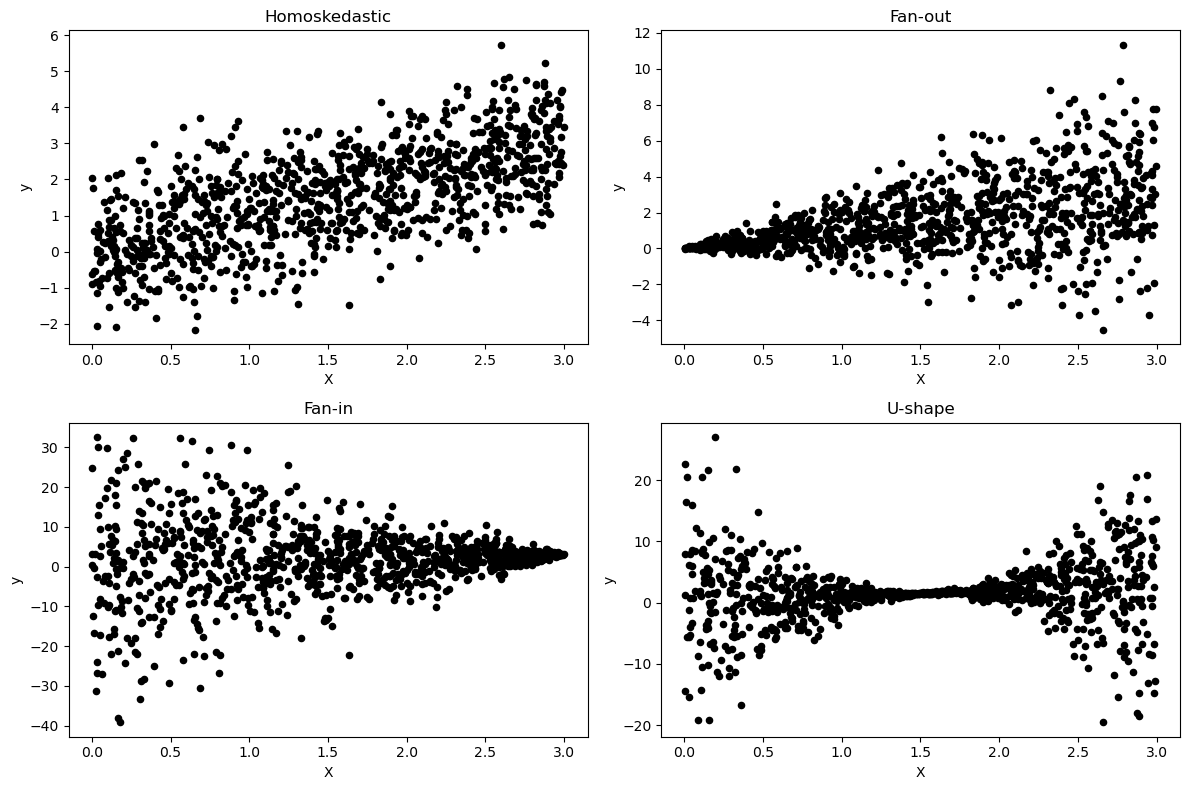

In [8]:
b0 = 0 # true intercept
b1 = 1 # true slope
sd = 1 # std. of baseline (homoskedasticity case)
a = 0.1 # controls magnitude of variation in the heteroskedastic case
b = 5 # controls shape of variation in the heteroskedastic case
n = 1000 # number of random variables

x, y1, y2, y3, y4 = getSample(b0, b1, sd, a, b, n)
y = [y1, y2, y3, y4]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ty = ["Homoskedastic", "Fan-out", "Fan-in", "U-shape"]

for i in range(2):
    for j in range(2):
        idx = i*2 + j
        ax[i,j].scatter(x, y[idx], c='black', s=20)
        ax[i,j].set_title(ty[idx])
        ax[i,j].set_xlabel("X")
        ax[i,j].set_ylabel("y")
        
plt.tight_layout()
plt.show()

### Examine false positive rate 

To examine the False Positive Rate (FPR), we simulated four different datasets where the true slope (b1) was set to zero. Therefore, the null hypothesis is known to be true, and a false positive is counted if the estimated slope coefficient is statistically significant. The simulation was conducted using a sample size of 1000 with 1000 replicates, and coefficients were evaluated at a significance level of 0.05.

In [9]:
b0 = 0.0 # true intercept
b1 = 0.0 # true slope
sd = 1 # std. of baseline (homoskedasticity case)
a = 0.1 # controls magnitude of variation
b = 5 # controls shape of variation 
n = 1000 # number of random variables
nrep = 1000 # number of replicates

coefs, ses, cis, p_vals = runSimulation(b0, b1, sd, a, b, n, nrep)

fpr = np.sum(p_vals < 0.05, axis=0) / nrep # proportion of times the null hypothesis was rejected

# print output
ty = ["Homoskedastic", "Fan-out", "Fan-in", "U-shape"]
for i, val in enumerate(fpr): 
    print("False Positive Rate for %s scenario: %.4f" % (ty[i], val))

False Positive Rate for Homoskedastic scenario: 0.0540
False Positive Rate for Fan-out scenario: 0.0700
False Positive Rate for Fan-in scenario: 0.0740
False Positive Rate for U-shape scenario: 0.1760


Based on the above simulation results, the FPR was lowest when homoscedastic variance was used to generate y. In contrast, for both the fan-in and fan-out variance structures, the FPR was higher than in the homoscedastic case, though both showed a similar magnitude. Finally, the U-shaped variance resulted larger FPR than the three cases.

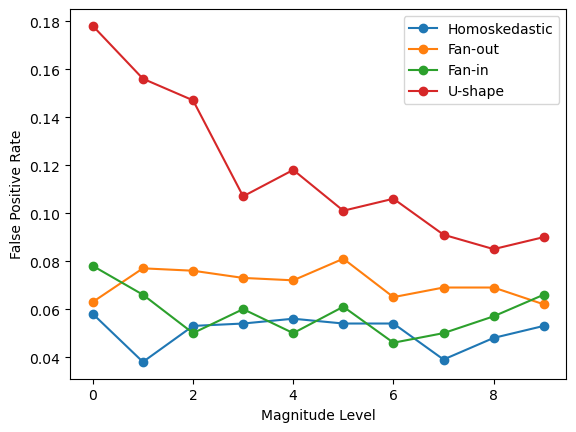

In [10]:
fs = [] # array to store FPR for different magnitudes of variation
for i in np.arange(0,20,2):
    a = i # controls magnitude of variation
    coefs, ses, cis, p_vals = runSimulation(b0, b1, sd, a, b, n, nrep)
    fpr = np.sum(p_vals < 0.05, axis=0) / nrep # proportion of times the null hypothesis was rejected
    fs.append(fpr)
    
fs = np.array(fs)

ty = ["Homoskedastic", "Fan-out", "Fan-in", "U-shape"]

for i in range(fs.shape[1]):
    plt.plot(fs[:, i], marker='o', label=f"{ty[i]}")

plt.xlabel("Magnitude Level")
plt.ylabel("False Positive Rate")
plt.legend()
plt.show()

In this step, we simulated the four variance scenarios using the previous parameters, except for the variance magnitude, which was increased by a factor of 2 and simulated over a range from 1 to 20. The plot above shows that the homoscedastic case achieved the lowest FPR, the fan-in and fan-out cases achieved similar magnitudes that were higher than the homoscedastic case, and the U-shaped variance produced the highest FPR.

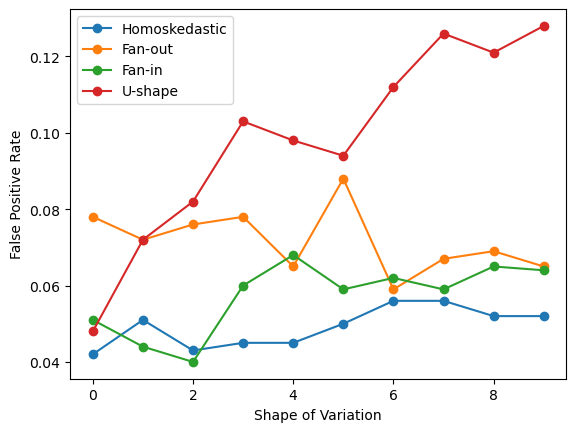

In [11]:
fs = [] # array to store FPR for different magnitudes of variation
for i in np.arange(0,20,2):
    b = i # controls shape of variation
    coefs, ses, cis, p_vals = runSimulation(b0, b1, sd, a, b, n, nrep)
    fpr = np.sum(p_vals < 0.05, axis=0) / nrep # proportion of times the null hypothesis was rejected
    fs.append(fpr)
    
fs = np.array(fs)

ty = ["Homoskedastic", "Fan-out", "Fan-in", "U-shape"]

for i in range(fs.shape[1]):
    plt.plot(fs[:, i], marker='o', label=f"{ty[i]}")

plt.xlabel("Shape of Variation")
plt.ylabel("False Positive Rate")
plt.legend()
plt.show()

Finally, as the shape parameter was increased, the FPR showed an upward trend in most cases. The plot above illustrates the FPR for different shape parameters.

### Power analysis

For the power analysis, we examined the same four scenarios where the null hypothesis is false. Here, we calculated the power based on the proportion of times the regression model rejected the null hypothesis. In the first simulation, we set the true intercept to 0.5 and simulated 1,000 random samples over 1,000 replicates.

In [12]:
b0 = 0.0 # true intercept
b1 = 0.5 # true slope
sd = 1 # std. of baseline (homoskedasticity case)
a = 0.1 # controls magnitude and shape of variation
b = 5 # controls magnitude and shape of variation 
n = 1000 # number of random variables
nrep = 1000 # number of replicates

coefs, ses, cis, p_vals = runSimulation(b0, b1, sd, a, b, n, nrep)
power = np.sum(p_vals < 0.05, axis=0) / nrep # proportion of times the null hypothesis was rejected

# print output
ty = ["Homoskedastic", "Fan-out", "Fan-in", "U-shape"]
for i, val in enumerate(power): 
    print("Power for %s scenario: %.4f" % (ty[i], val))

Power for Homoskedastic scenario: 1.0000
Power for Fan-out scenario: 1.0000
Power for Fan-in scenario: 0.3710
Power for U-shape scenario: 0.6770


Here, we can see that for a slope effect of 0.5, the homoscedastic variance structure outperforms the other variance structures, whereas the fan-out variance performs better than the fan-in. However, the U-shaped variance case was the worst among the three scenarios.

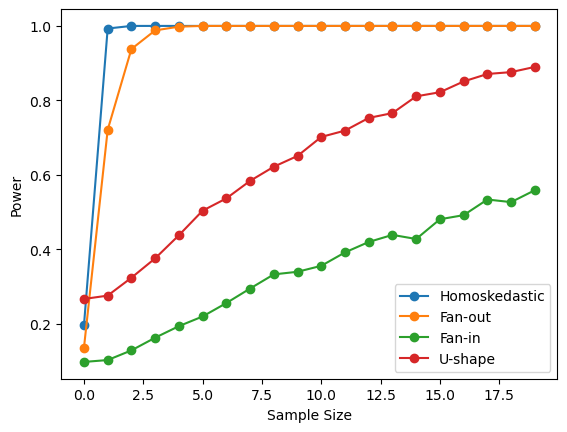

In [13]:
pw = [] # array to store power for different sample size
for i in np.arange(10,2000,100):
    n = i # sample size
    coefs, ses, cis, p_vals = runSimulation(b0, b1, sd, a, b, n, nrep)
    power = np.sum(p_vals < 0.05, axis=0) / nrep # proportion of times the null hypothesis was rejected
    pw.append(power)
    
pw = np.array(pw)

ty = ["Homoskedastic", "Fan-out", "Fan-in", "U-shape"]

for i in range(pw.shape[1]):
    plt.plot(pw[:, i], marker='o', label=f"{ty[i]}")

plt.xlabel("Sample Size")
plt.ylabel("Power")
plt.legend()
plt.show()

Finally, we can see that when we increase the sample size, the power also increases for all the case.

### Accuracy of estimates

In [14]:
b0 = 0.0 # true intercept
b1 = 1.5 # true slope
sd = 1 # std. of baseline (homoskedasticity case)
a = 0.1 # controls magnitude and shape of variation
b = 5 # controls magnitude and shape of variation 
n = 1000 # number of random variables
nrep = 100 # number of replicates

coefs, ses, cis, p_vals = runSimulation(b0, b1, sd, a, b, n, nrep)

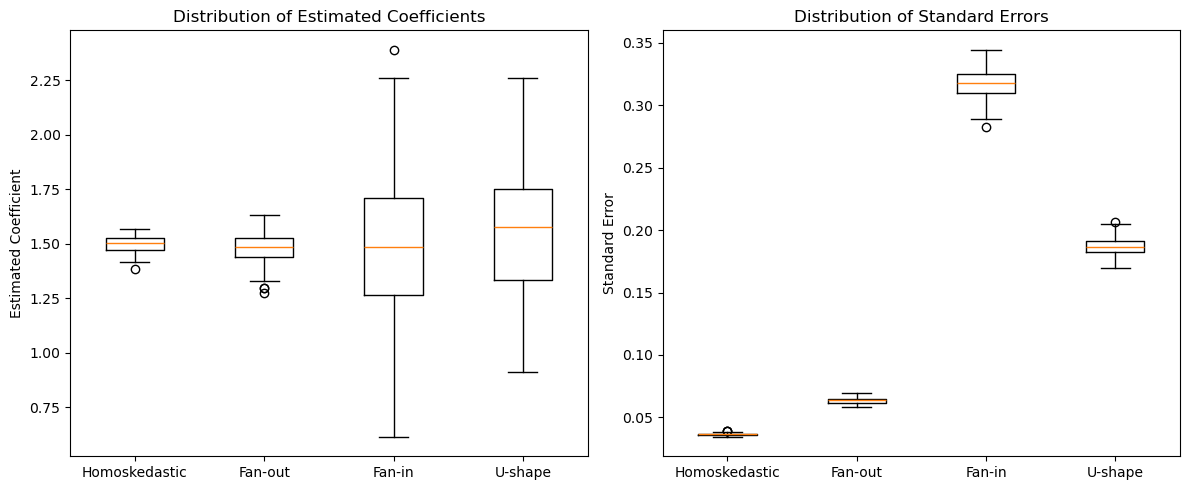

In [15]:
ty = ["Homoskedastic", "Fan-out", "Fan-in", "U-shape"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# plot coef
ax[0].boxplot(coefs, tick_labels=ty)
ax[0].set_ylabel("Estimated Coefficient")
ax[0].set_title("Distribution of Estimated Coefficients")

# plot SE
ax[1].boxplot(ses, tick_labels=ty)
ax[1].set_ylabel("Standard Error")
ax[1].set_title("Distribution of Standard Errors")

plt.tight_layout()
plt.show()


To analyze the accuracy of the estimates, we plotted the distribution of coefficients and standard errors with a true slope effect of 1.5. The results show that the mean estimated coefficient remains close to 1.5 across all simulations, demonstrating unbiased estimation regardless of the variance structure. The homoscedastic case was the most robust, with tightly clustered coefficients and the lowest standard errors. While the other heteroscedastic structures stayed centered on the true value, they introduced much higher variability. Specifically, the fan-in and U-shaped scenarios had the largest standard errors.